In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, InterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

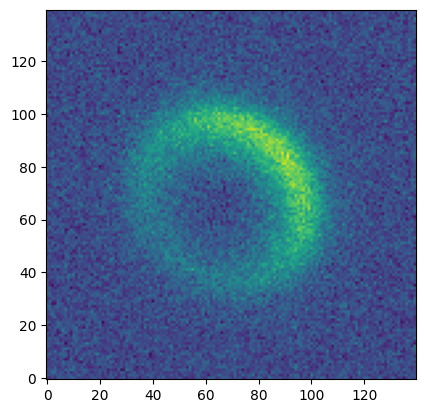

In [3]:
name = "inject_disk_inc30_spf0_betaneg.fits"
target_img = jnp.array(fits.getdata("inject_disk_inc30_spf0_betaneg.fits"))
plt.imshow(target_img,origin='lower')
err_map = jnp.ones(target_img.shape)*10

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['inclination'] = 32
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5

misc_params = Parameter_Index.misc_params
misc_params['flux_scaling'] = 1e4


In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, misc_params)

In [5]:
opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
opt.initialize_knots(target_img) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

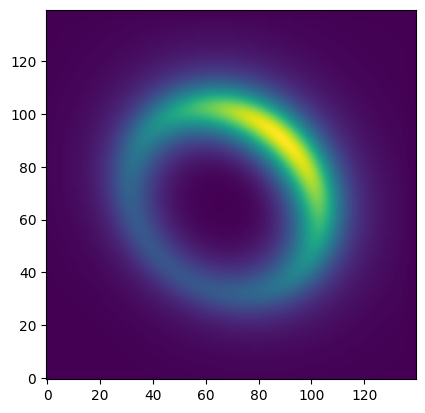

In [6]:
plt.imshow(opt.get_model(),origin='lower')

In [7]:
fit_keys = ['sma', 'inclination', 'position_angle', 'beta','knot_values']
logscaled_params = ['knot_values']
array_params = ['knot_values']
bounds = ([0, 0, 0,-5, np.zeros(opt.spf_params["num_knots"])],
          [150, 180, 400,  5,1e4*np.ones(opt.spf_params["num_knots"])])

opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_img, err_map, use_grad = True, disp_soln = True, iters = 2000)
optimal_image = opt.get_model()

  message: ABNORMAL: 
  success: False
   status: 2
      fun: 4.079453495558961
        x: [ 2.797e+01  3.201e+01  4.800e+01  4.664e-01  9.723e-01
             4.358e-01  2.049e-02 -2.669e-01 -5.182e-01]
      nit: 1
      jac: [ 5.480e-02 -1.937e-02  1.994e-04  6.616e-02 -2.885e-01
            -1.468e-01 -3.779e-02 -3.883e-02 -2.147e-02]
     nfev: 33
     njev: 33
 hess_inv: <9x9 LbfgsInvHessProduct with dtype=float64>


Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': np.float64(27.971701621929686), 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(0.46638030762895427), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(32.00925852798734), 'position_angle': np.float64(47.99990308816433), 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.52991926, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.52991926, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([2.59044868, 1.5147743 , 1.        , 0.75022884, 0.58349099],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(2157.22930845, dtype=float64)}


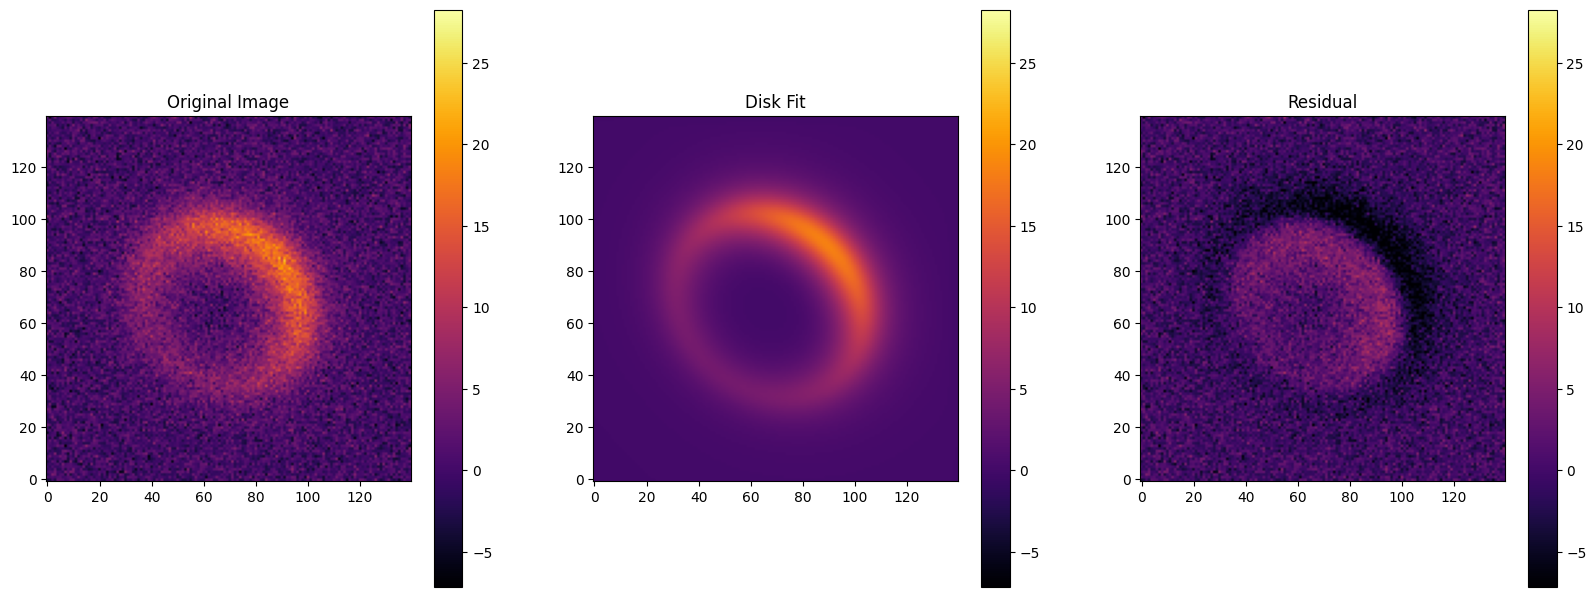

In [13]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 95)

im = axes[0].imshow(target_image/5, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image/5-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout
plt.savefig('{}_scipyminimize_img.png'.format(name))

In [ ]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(knot_locs,[4.0,2.0,1.0,0.5,0.1],marker='x',zorder=10)

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.savefig('{}_scipyminimize_spf.png'.format(name))

In [ ]:
# For MCMC, spline values are log scaled, the optimizer class passes them in as log(spf_params) and they are exponated in the lambda expression, this evens out the markov chains
# helping MCMC work better

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=2000, burns=500)

In [ ]:
mc_model.set_discarded_iters(1000)
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 95)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout()
plt.savefig('{}_mcmc_img.png'.format(name))

In [ ]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, opt.spf_params['knot_values'])
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(knot_locs,[4.0,2.0,1.0,0.5,0.1],marker='x',zorder=10)
for i in np.random.random(100)*(len(mc_model.scaled_chain)-500):
    j = int(np.random.random()*100)
    i = int(i)+500
    kvals = mc_model.scaled_chain[i,j,4:]
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(x_vals),color='tab:blue',alpha=0.2)
plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.ylim(0,6)
print(mc_model.scaled_chain.shape)
plt.savefig('{}_mcmc_spf.png'.format(name))

In [ ]:
mc_soln = mc_model.get_theta_median()
mc_model.show_corner_plot(fit_keys+['kv2','kv3','kv4','kv5'], truths=mc_soln, scaled=True)

In [ ]:
mc_model.plot_chains(fit_keys+['kv2','kv3','kv4','kv5'])

In [ ]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5


def recover_disk(injected_disk):
    target_img = jnp.array(fits.getdata(injected_disk))
    err_map = jnp.ones(target_img.shape)*10
    start_disk_params['inclination'] = float(injected_disk.split("_")[2][3:4])
    spf_num = float(injected_disk.split("_")[3][3])
    if spf_num == 0:
        spf_truth = [4.0,2.0,1.0,0.5,0.1]
    elif spf_num == 1:
        spf_truth = [8.0,4.0,1.0,0.2,0.4]
    elif spf_num == 2:
        spf_truth = [2.0,3.0,2.0,1.0,0.5]
    opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params)
    opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
    opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
    opt.initialize_knots(target_img) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

    #scipy minimize
    fit_keys = ['sma', 'inclination', 'position_angle', 'e','beta','knot_values']
    logscaled_params = ['knot_values']
    array_params = ['knot_values']
    bounds = ([0, 0, 0,0,-5, np.zeros(opt.spf_params["num_knots"])],
            [150, 180, 400,  1,5,1e4*np.ones(opt.spf_params["num_knots"])])

    opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_img, err_map, use_grad = True, disp_soln = True, iters = 2000)
    optimal_image = opt.get_model()

    opt.scale_spline_to_fixed_point(0, 1)
    opt.print_params()
    target_image = target_img
    fig, axes = plt.subplots(1,3, figsize=(20,10))

    mask = OptimizeUtils.get_mask(target_image)
    vmin = np.nanpercentile(target_image[mask], 10)
    vmax = np.nanpercentile(target_image[mask], 95)

    im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
    axes[0].set_title("Original Image")
    plt.colorbar(im, ax=axes[0], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
    axes[1].set_title("Disk Fit")
    plt.colorbar(im, ax=axes[1], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
    axes[2].set_title("Residual")
    plt.colorbar(im, ax=axes[2], shrink=0.75)
    im.set_clim(vmin, vmax)

    plt.tight_layout
    plt.savefig('{}_scipyminimize_img.png'.format(name))

    knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
    x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
    plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(knot_locs))
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(x_vals))
    plt.scatter(knot_locs,spf_truth,marker='x',zorder=10)

    plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
    plt.savefig('{}_scipyminimize_spf.png'.format(name))

    ##MCMC
    mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=2000, burns=500)
    mc_model.set_discarded_iters(500)
    opt.scale_spline_to_fixed_point(0, 1)
    opt.print_params()
    target_image = target_img
    fig, axes = plt.subplots(1,3, figsize=(20,10))

    mask = OptimizeUtils.get_mask(target_image)
    vmin = np.nanpercentile(target_image[mask], 10)
    vmax = np.nanpercentile(target_image[mask], 95)

    im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
    axes[0].set_title("Original Image")
    plt.colorbar(im, ax=axes[0], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
    axes[1].set_title("Disk Fit")
    plt.colorbar(im, ax=axes[1], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
    axes[2].set_title("Residual")
    plt.colorbar(im, ax=axes[2], shrink=0.75)
    im.set_clim(vmin, vmax)

    plt.tight_layout()
    plt.savefig('{}_mcmc_img.png'.format(name))

    knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
    x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
    plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(knot_locs))
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(x_vals))
    plt.scatter(knot_locs,spf_truth,marker='x',zorder=10)
    for i in np.random.random(100)*(len(mc_model.scaled_chain)-500):
        j = int(np.random.random()*100)
        i = int(i)+500
        kvals = mc_model.scaled_chain[i,j,9:]
        plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(x_vals)/InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(90),color='tab:blue',alpha=0.2)
    plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
    plt.ylim(0,10)

    plt.savefig('{}_mcmc_spf.png'.format(name))

    print('for disk {}'.format(injected_disk)),'beta is', opt.disk_params['beta'])